# 02 — How I collected and annotated the data

This notebook explains how I turned Mapillary street imagery into a labeled dataset of LA parking signs: what I tried, what I changed along the way, and what the numbers came out to. Everything here is recomputed from the files in `data/`, so the figures match the dataset as it stands.

The pipeline code lives in `src/vlm_parking/` and `scripts/`; see [FILE_MAP.md](../Reference/FILE_MAP.md).

**The short version**

| Stage | Count |
|---|---|
| Images screened across 5 LA areas | 104,230 |
| Images passing the pre-screen | 19,321 |
| Sign crops after merging stacked panels | 22,239 |
| Unique physical signs after deduplication | 5,218 |
| Candidates I triaged | 5,218 |
| Accepted, OCR-confirmed cohort | 692 |
| **Signs I fully transcribed** | **272** |
| Queries generated from them | 4,021 |

In [1]:
import sys
from pathlib import Path

SRC = Path("../src").resolve()          # import vlm_parking even if this kernel isn't the project venv
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

DATA = Path("../data")
CROPS = DATA / "collect"

signs = pd.read_parquet(DATA / "queries/signs_v1.parquet")
queries = pd.read_parquet(DATA / "queries/queries_v1.parquet")
signs["sign"] = signs.sign_json.map(json.loads)
print(f"{len(signs)} labeled signs, {len(queries):,} queries")

272 labeled signs, 4,021 queries


## 1. Picking a source

I needed photos of real LA parking signs, each with enough metadata to credit the photographer, and enough of them to stratify by neighbourhood.

I considered the **Mapillary Traffic Sign Dataset** (100k images, ~300 sign classes), but rejected it:

- it samples the world roughly evenly, so all of LA contributes a handful of images;
- it labels sign *classes*, not the text, so I'd still transcribe everything myself;
- its licence is non-commercial;
- and it is drawn from the same Mapillary pool I can query directly.

So I used the **Mapillary Graph API**: free, CC BY-SA, and it gives me each image's location, capture date, camera heading and photographer. The five areas I chose are permit-heavy and dense, which is where LA's complicated signs are:

`westwood`, `koreatown`, `downtown` (Historic Core + Arts District), `hollywood` (incl. East Hollywood), `venice_mar_vista` — bounding boxes in `src/vlm_parking/prescreen.py`.

In [2]:
from vlm_parking.prescreen import AREAS, Criteria

for name, box in AREAS.items():
    print(f"{name:18} lon {box[0]:>9.3f}..{box[2]:<9.3f} lat {box[1]:.3f}..{box[3]:.3f}")
print()
print("Pre-screen thresholds:", Criteria())

westwood           lon  -118.455..-118.435  lat 34.045..34.065
koreatown          lon  -118.310..-118.290  lat 34.052..34.070
downtown           lon  -118.258..-118.225  lat 34.035..34.055
hollywood          lon  -118.345..-118.285  lat 34.088..34.105
venice_mar_vista   lon  -118.480..-118.420  lat 33.985..34.015

Pre-screen thresholds: Criteria(min_long_side=1920, min_sign_px=60, min_aspect=1.1, edge_margin=0.01, overhead_frac=0.2, freeway_buffer_m=30)


## 2. Why I don't sample randomly

My first probe pulled 100 random Westwood images and asked me to count legible parking signs. Almost none qualified. Mapillary detected 344 front-facing signs across those 100 images, but half were **under 22 pixels tall** on a 2048-px image — nowhere near readable — and the box also included a stretch of the I-405, where there are no parking signs at all.

That killed the idea of reviewing raw images. Instead I built a pre-screen that runs before any human looks at anything:

1. **Resolution:** at least 1920 px on the long side.
2. **Not a freeway:** more than 30 m from an OSM motorway line (fetched from Overpass and cached). This alone removed about half of Westwood's images.
3. **A real sign in frame:** Mapillary's per-image detections must include a front-facing sign that is at least 60 px tall (on the 2048 scale), taller than it is wide, not touching the frame edge, and not sitting entirely in the top fifth of the image (overhead signs).

The size threshold is deliberately loose. A stricter one would have saved me triage time but thrown away the hard-to-read signs, which are exactly the ones the benchmark should contain.

In [3]:
funnel = []
for area in sorted(AREAS):
    screened = sum(1 for _ in open(CROPS / area / "screened.jsonl"))
    passing = sum(1 for line in open(CROPS / area / "screened.jsonl") if '"passing": true' in line)
    stacks = sum(1 for _ in open(CROPS / area / "stacks.jsonl"))
    cands = len(pd.read_csv(CROPS / area / "candidates.csv"))
    funnel.append({"area": area, "screened": screened, "passing": passing, "stacks": stacks, "candidates": cands})
funnel = pd.DataFrame(funnel).set_index("area")
funnel.loc["TOTAL"] = funnel.sum()
display(funnel.map("{:,}".format))
print(f"pre-screen pass rate: {funnel.loc['TOTAL','passing'] / funnel.loc['TOTAL','screened']:.1%}")

,screened,passing,stacks,candidates
area,,,,
downtown,"21,990","4,260","5,013","1,213"
hollywood,"29,374","6,173","7,184","1,567"
koreatown,"19,530","3,071","3,396",977
venice_mar_vista,"27,362","4,385","4,891",891
westwood,"5,974","1,432","1,755",570
TOTAL,"104,230","19,321","22,239","5,218"


pre-screen pass rate: 18.5%


## 3. Cropping: one sign, not one plate

Mapillary detects each *plate* separately, so a pole with three plates gives three boxes. That's wrong for my purposes: the three plates are one sign, and a query about it needs all of them. If I cropped them separately I'd have three "single-panel signs" with wrong answers, and I'd lose exactly the multi-panel stacks I care about.

So I merge detections that overlap horizontally and sit close together vertically into one box, then cut the crop from the **original full-resolution photo** (not the 2048-px copy) with 12% padding. For one Koreatown sign this turned 4 detections into 1 crop containing both a street-cleaning plate and a 2-hour limit plate, at 170×492 px instead of 86×250.

downtown/470217334091689_0  (5 panels: no_stopping 07:00-09:00; no_stopping 16:00-18:00; time_limited 09:00-16:00; time_limited 18:00-20:00; time_limited 08:00-20:00)


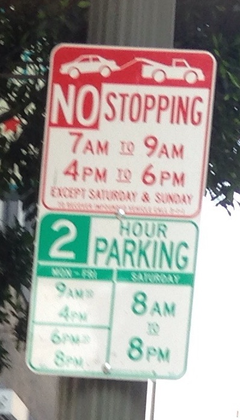

In [4]:
def show_crop(sign_id, height=420):
    row = signs[signs.sign_id == sign_id].iloc[0]
    im = Image.open(CROPS / row.crop_path).convert("RGB")
    im = im.resize((max(1, int(im.width * height / im.height)), height), Image.LANCZOS)
    panels = [f"{p['rule']} {p['start'] or 'all day'}" + (f"-{p['end']}" if p['start'] else "") for p in row.sign["panels"]]
    print(f"{sign_id}  ({row.n_panels} panels: {'; '.join(panels)})")
    display(im)

# a multi-panel stack that the merge step kept together
show_crop(signs.sort_values("n_panels", ascending=False).iloc[0].sign_id)

## 4. OCR: a reject-only filter

I run RapidOCR (the PP-OCR models) over every crop. It would be tempting to keep only crops where OCR reads parking words — that would have cut my triage pile by 85%. I checked what that would cost first.

On my first 100 labeled signs, OCR recognised parking text in only **38 of the 90** crops I judged usable. Filtering on OCR would have discarded 58% of the usable signs, and not at random: it drops faded, low-contrast and small signs. Those are the ones a VLM is most likely to misread too, so condition A would have been made artificially easy and the perception gap I'm trying to measure would shrink.

So OCR is only allowed to **reject**: crops whose text clearly reads as something else (speed limits, school zones, Metro stops, bike lanes, "do not block intersection"). Everything else, including crops where OCR finds nothing at all, goes to me. Across all 22,239 crops that rejected 3,619.

*(Later, for throughput, I did restrict the triage display to OCR-confirmed crops — see §6. That's a selection rule I have to report, and it's why the accepted cohort is defined as "triage-accepted **and** OCR-confirmed".)*

In [5]:
from vlm_parking.collect import parking_text_score

for texts in [["2HOUR", "PARKING", "8AM6PM"], ["R", "4ouk", "FARKING"], ["8AM10AM", "THURSDAY"], ["SPEED", "LIMIT"], []]:
    r = parking_text_score(texts)
    print(f"{str(texts):<40} -> {r['status']:<10} keep={r['keep']}")

['2HOUR', 'PARKING', '8AM6PM']           -> parking    keep=True
['R', '4ouk', 'FARKING']                 -> parking    keep=True
['8AM10AM', 'THURSDAY']                  -> parking    keep=True
['SPEED', 'LIMIT']                       -> other      keep=False
[]                                       -> unknown    keep=True


## 5. The same sign, photographed five times

Mapillary's coverage comes from drives, so one pole appears in many frames, and sometimes in several drives years apart. Counting those as separate signs would inflate the dataset and break the statistics later (the bootstrap resamples over signs, assuming they're independent).

I cluster crops whose cameras were within 25 m of each other and which either look alike (perceptual hash) or whose OCR text largely agrees, then keep the sharpest, largest view. Across the five areas that collapsed 22,239 crops into 5,218 unique signs.

## 6. Triage

I built a small browser tool (`scripts/triage.py`) that shows 40 crops a page. I click the bad ones, press Enter, and the rest are accepted. Decisions save after every page.

The first round showed everything except the OCR-rejected crops: 3,642 candidates, of which I accepted 516 (14%). That took about 45 minutes. Working through it I learned that the queue is strongly ordered — accept rate was 87% in the first tenth and under 6% after the first third — because crops OCR could read come first.

For the second round I restricted the display to OCR-confirmed crops, which is a deliberate trade: about 10–15 usable signs lost, in exchange for far less time spent rejecting junk. The accepted cohort is therefore **triage-accepted and OCR-confirmed** (`src/vlm_parking/dataset.py`).

In [6]:
triage = pd.read_csv(CROPS / "triage.csv")
cands = pd.concat([pd.read_csv(p) for p in sorted(CROPS.glob("*/candidates.csv"))], ignore_index=True)
m = cands.merge(triage, on="candidate_id", how="left")
print("triage decisions:", m.decision.value_counts().to_dict())
print("accept rate among OCR-confirmed crops:",
      f"{m[m.ocr_status.eq('parking')].decision.eq('accept').mean():.1%}",
      "| among OCR-unknown:", f"{m[m.ocr_status.ne('parking')].decision.eq('accept').mean():.1%}")

triage decisions: {'reject': 4383, 'accept': 828, 'maybe': 7}
accept rate among OCR-confirmed crops: 33.4% | among OCR-unknown: 4.3%


## 7. The schema and the annotation guide

Before labeling anything I wrote down the target structure and the rules, because every ambiguity I resolved twice would be an inconsistency in the ground truth.

A **panel** is one rule with one time window: rule type, an explicit list of days, a start and end time (or "all day"), an optional time limit, an optional permit district, and flags for tow-away and holidays. A **sign** is an ordered list of panels plus image-quality flags and an `ambiguous` flag.

The rules that took the most thought (all in [ANNOTATION_GUIDE.md](../ANNOTATION_GUIDE.md)):

- **One plate can be several panels.** "7AM–9AM 4PM–7PM" is two panels; a plate with weekday and weekend columns is one panel per column, left before right.
- **Overnight windows stay one panel** with start > end, and the days are the days the window *starts*.
- **An exemption plate ("DISTRICT NO. 31 PERMITS EXEMPT") is not a panel.** It sets the district on the panels above it — and never on a street-cleaning panel, because permits don't exempt street sweeping.
- **Unreadable fine print means reject.** If a column header or an "EXCEPT SUNDAY" line could change the rule and I can't read it, the sign is out. Guessing would put an assumption into the ground truth.
- **Ambiguous wording is flagged, not guessed.** One Downtown sign read "8AM TO 8PM / SATURDAY / EXCEPT SUNDAY", which has two defensible readings; such signs are transcribed, flagged, and excluded from query generation.

In [9]:
from vlm_parking.prompts import render_sign
from vlm_parking.schema import Sign

example = Sign(**signs[signs.n_panels >= 3].iloc[0].sign)
print(example.sign_id)
print(render_sign(example))

venice_mar_vista/905807009964287_1
The sign has the following panels, top to bottom:
Panel 0: No parking; 02:00-06:00; every day
Panel 1: No parking; 08:00-10:00; Monday
Panel 2: Time-limited parking; limit 120 minutes; 08:00-18:00; every day


## 8. The evaluator

Ground truth for a *query* never comes from me — it comes from code. I transcribe the sign once, and `evaluate(sign, query)` answers any question about it. That's what makes 4,021 examples affordable.

The semantics I settled on:

1. A query is a **stay**, and the whole stay must be legal; arriving at 7:30 for an hour under an 8–10 restriction is illegal.
2. Windows are half-open: in force at the start minute, over at the end minute.
3. Time limits count only the time spent inside the window; meters are assumed paid.
4. Permits exempt only the panel they're written on.
5. Queries never fall on holidays.
6. When several panels are violated, the most restrictive governs, and that's the panel I expect a model to name.

I wrote 37 tests for it (`tests/test_evaluator.py`) covering each rule type, overnight wraparound, boundary minutes, day-of-week edges, permits, durations and multi-panel conflicts. While labeling I also spot-checked real signs with the query box built into the labeling tool, which is the plan's "30 hand-checks" gate done continuously instead of in one sitting.

In [10]:
from vlm_parking.evaluator import evaluate
from vlm_parking.schema import Query

# the queries the generator produced for this sign, re-checked against the evaluator
mine = queries[queries.sign_id == example.sign_id].sort_values(["type", "day"])
for r in mine.groupby("type").head(2).itertuples():
    q = Query(day=r.day, time=r.time, duration_min=int(r.duration_min),
              permit_district=r.permit_district if isinstance(r.permit_district, str) else None)
    v = evaluate(example, q)
    same_panel = v.governing_panel == r.governing_panel or (v.governing_panel is None and pd.isna(r.governing_panel))
    assert v.verdict == r.verdict and same_panel  # the stored ground truth is exactly what the evaluator says
    print(f"{r.type:<18} {q.day} {q.time} {q.duration_min:>3}min permit={str(q.permit_district):<5}"
          f" -> {v.verdict:<8} panel {str(v.governing_panel):<4} {v.reason[:60]}")

boundary           FRI 01:03  60min permit=None  -> illegal  panel 0    stay overlaps panel 0 (no_parking, 02:00-06:00, every day) b
boundary           MON 07:43  15min permit=None  -> legal    panel None no panel is violated by this stay
clear_illegal      MON 14:19 180min permit=None  -> illegal  panel 2    180 min inside panel 2 (time_limited, 08:00-18:00, every day
clear_illegal      SAT 04:37  15min permit=None  -> illegal  panel 0    stay overlaps panel 0 (no_parking, 02:00-06:00, every day) b
clear_legal        FRI 21:11 240min permit=None  -> legal    panel None no panel is violated by this stay
clear_legal        MON 00:21  45min permit=None  -> legal    panel None no panel is violated by this stay
permit_irrelevant  FRI 09:47  30min permit=None  -> legal    panel None no panel is violated by this stay
permit_irrelevant  FRI 09:47  30min permit=43    -> legal    panel None no panel is violated by this stay


## 9. Labeling

I labeled every accepted sign myself, blind, in a second browser tool (`scripts/label.py`): the crop on the left, one card per panel on the right, and an evaluator box underneath for sanity checks. No model pre-fill — the original plan had a frontier model pre-filling each sign, but labeling turned out to take about 9 seconds per sign, so assistance would have saved little and would have put model output into my ground truth.

The first 100 signs were a stratified sample by detected panel count, so that complex signs were represented from the start rather than appearing only at the end.

**What happened: 272 labeled, 420 rejected.** The reject reasons are the interesting part.

status: {'rejected': 420, 'labeled': 272}
median time: 9s per labeled sign, 2s per reject, 2.4h total


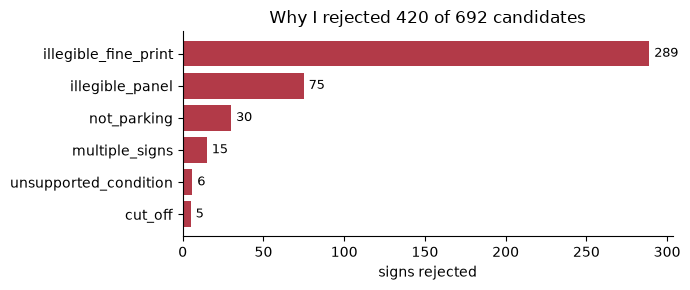

In [11]:
con = sqlite3.connect(DATA / "labels/labels.sqlite")
labels = pd.read_sql("select * from labels where round = 1", con)
labels = labels[labels.candidate_id.isin(cands[cands.ocr_status.eq("parking")].candidate_id)]
print("status:", labels.status.value_counts().to_dict())
print(f"median time: {labels[labels.status=='labeled'].seconds.median():.0f}s per labeled sign, "
      f"{labels[labels.status=='rejected'].seconds.median():.0f}s per reject, {labels.seconds.sum()/3600:.1f}h total")

reasons = labels.reject_reason.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(reasons.index, reasons.values, color="#b23a48")
ax.set_xlabel("signs rejected"); ax.set_title("Why I rejected 420 of 692 candidates")
for i, v in enumerate(reasons.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**42% of the cohort failed on fine print.** LA signs put rule-changing text in small type: the column headers on two-column time-limit plates ("MON–SAT" / "SUNDAY"), "EXCEPT SUNDAY" lines, vehicle-type exceptions. At the distance a car-mounted camera photographs a sign, that text is usually a smudge even in the original 4032-px photo. I checked several of these by zooming into the originals before rejecting them.

I treat this as a result, not just attrition: **street-level imagery of the kind a driving system would collect often cannot resolve the text that determines the rule.**

One crop I caught late: the detector had missed the lower plates of a Hollywood sign, so the crop showed only the top plate while my label described the whole stack (I had read the full photo). I re-cut that crop from the original with `scripts/recrop.py` and logged the change in `data/collect/recrops.csv`. I checked the other 15 signs whose labels listed more panels than the detector found; they were all legitimate multi-window plates.

## 10. The dataset

272 signs, 420 panels. It's smaller than the 500 I planned, but the complexity tail survived, which matters more for the main figure: the x-axis is panel count.

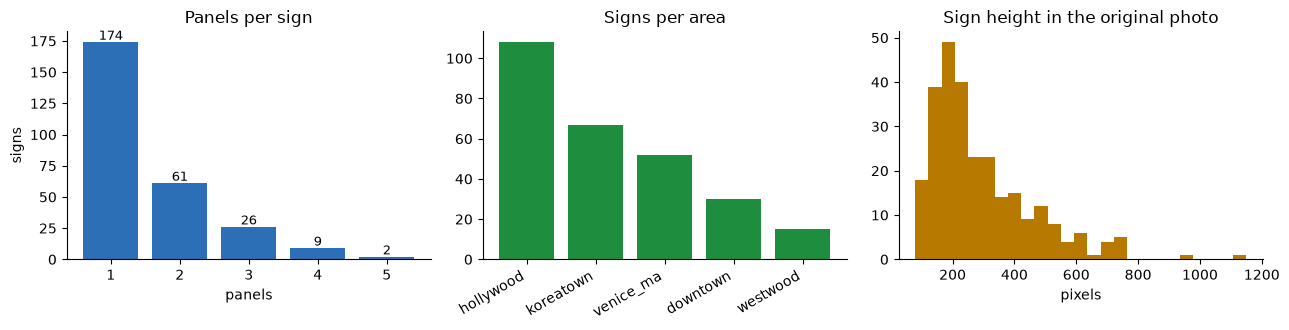

rule coverage: {'no_parking': 233, 'time_limited': 114, 'no_stopping': 67, 'permit_only': 6}
capture years: {2013: 5, 2015: 18, 2016: 63, 2017: 68, 2018: 9, 2019: 8, 2020: 51, 2021: 43, 2024: 3, 2026: 4}
signs with a permit district: 13


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

pc = signs.n_panels.value_counts().sort_index()
axes[0].bar(pc.index.astype(str), pc.values, color="#2c6fb7")
axes[0].set_title("Panels per sign"); axes[0].set_xlabel("panels"); axes[0].set_ylabel("signs")
for i, v in enumerate(pc.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=9)

ar = signs.area.value_counts()
axes[1].bar(range(len(ar)), ar.values, color="#1e8e3e")
axes[1].set_xticks(range(len(ar))); axes[1].set_xticklabels([a[:9] for a in ar.index], rotation=30, ha="right")
axes[1].set_title("Signs per area")

axes[2].hist(signs.height_native, bins=25, color="#b77900")
axes[2].set_title("Sign height in the original photo"); axes[2].set_xlabel("pixels")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

rules = pd.Series([p["rule"] for s in signs.sign for p in s["panels"]]).value_counts()
print("rule coverage:", rules.to_dict())
print("capture years:", signs.year.value_counts().sort_index().to_dict())
print("signs with a permit district:", signs.sign.map(lambda s: any(p["district"] for p in s["panels"])).sum())

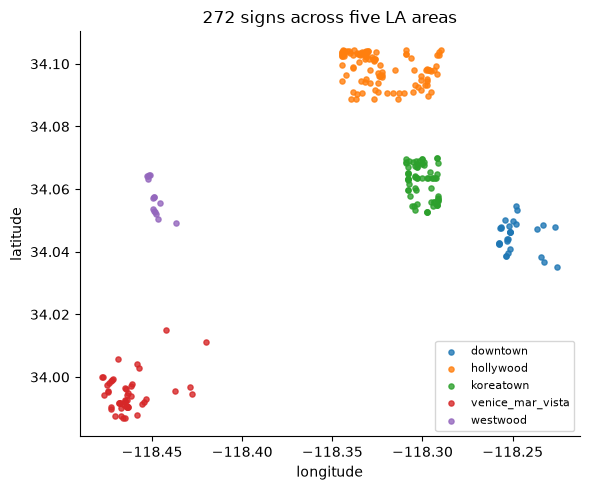

In [13]:
# where the signs are
fig, ax = plt.subplots(figsize=(6, 5))
for area, g in signs.groupby("area"):
    ax.scatter(g.lon, g.lat, s=14, label=area, alpha=0.8)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_title("272 signs across five LA areas")
ax.legend(fontsize=8, loc="lower right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 11. What I'd tell someone repeating this

- **Filter before you look.** Human review time is the scarce resource; spending it on images that can't contain a usable sign is the main way this project could have failed.
- **Never let a model decide what goes in.** OCR as a gate would have made my headline number look better and meant less.
- **Write the annotation rules before labeling, and add to them the moment a new case appears.** Every rule in the guide came from a sign that confused me once; writing it down meant the next twenty were consistent.
- **Let code answer the queries.** Transcribing 272 signs bought me 4,021 examples with exact ground truth, including boundary cases I would never have thought to write by hand.
- **Expect the fine print to be the limit.** If I did this again I'd photograph signs myself for the complex tail, and keep the street imagery for the wide, realistic sample.

**Known limitations of the dataset**

1. Selection is "OCR-confirmed, then human-verified", so condition A is somewhat easier than LA signs in general.
2. Crops are tight on the sign, so no surrounding context (kerb colour, arrows in situ, neighbouring signs).
3. Only four rule types survived: no-parking, time-limited, no-stopping and permit-only. No meters, loading zones or no-standing.
4. 272 signs means roughly ±5–6 points of uncertainty on overall accuracy, and wider per panel-count bin.
5. Every label is mine alone; a blind re-label of 50 signs (`--round 2`) will give a self-consistency number, which is the honest substitute for inter-annotator agreement.